# Astrocyte ion homeostasis model (v2)



# Astrocyte ion homeostasis model (v2)

Replication of Thapaliya et al. (2023), Frontiers in Cellular Neuroscience.
Single-compartment astrocyte model of Na+/K+/Cl-/Ca2+ homeostasis.

v2 adds:
  - Cytosolic calcium dynamics (Ca2+, ER store, IP3, h inactivation)
  - NMDA receptor: 5-state Markov model
  - AMPA receptor: 6-state Markov model
  - SERCA pump, ER leak, IP3R-mediated Ca2+ release
  - G-protein cascade for IP3 production
  - Calcium buffering (B_cyt)
  - Fixed electroneutrality: dCl = dNa + dK + 2*dCa
  - Fixed unit conversion for NMDA/AMPA max currents (pA -> pA/um2)

NOTE: G_NBC and G_NHE are kept non-zero here (active transporters).
      To match the Fortran reference exactly, set both to 0.


# Imports and parameters

In [155]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

params = {
    'Faraday': 96485.0, #C/mol
    'VR': 0.33,
    'v_T': 26.6995, #mV #thermal voltage


    'G_na':171.6117, # uMmV^-1s^-1 #Ion channel #calibrated value (original value taken from paper: 226.94)
    'G_NKCC':9.568,# uMmV^-1s^-1 ##Electroneutral cotransporter
    'G_NBC': 130.74, # uMmV^-1s^-1 #Can be electroneutral or electrogenic cotransporter
    'G_NHE': 131, # uMmV^-1s^-1 #Electroneutral cotransporter
    'G_k': 8285.7902, #uMmV^-1s^-1 #Ion channel #calibrated value (original value taken from paper: 6907.77)
    'G_KCC1':1.728, #uMmV^-1s^-1 #Electroneutral cotransporter
    'G_cl': 151.93, #uMmV^-1s^-1 #Ion channel
    'G_TRPV4': 0.000317, # µM/(mV*s) #Ion channel

    'v': -88.79, #mV #Resting membrane potential
    'pH_o': 7.35, #Extracellular pH
    'pH_i': 7.33, #Intracellular pH
    'pKa': 6.1,
    's': 0.225 , #μMPa^-1
    'P_CO2': 5332.9, #Pa
    'k_h': 0.8, #uM

    'rho_conv':13605.0765, # conversion factor, converting pA/um2 to uM/s

    'I_NCX_max': 0.001, # pAuM^-2
    'K_NCX_mN': 87500 , #uM
    'K_NCX_mC': 1380 , #uM
    'eta_NCX':0.35 , #unitless
    'k_sat': 0.1, #unitless

    'K_GluT_mN':15000, #uM
    'K_GluT_mK': 5000, #uM
    'K_GluT_mg': 34, #uM
    'I_GluT_max':0.1, #pAum^-2

    'Vol_a':168, #um^-3
    'Na_bath': 149200, #uM
    'Na_diff': 50, #s^-1
    'K_bath': 2934.0, #uM
    'K_diff': 50, # s^-1
    'Na_a':18730, #uM
    'Na_o':149200,# uM
    'K_a': 92680, #uM
    'K_o': 2934, #uM
    'Cl_a':8215.0, #uM
    'Cl_o':149200 + 2934, #uM
    'Ca_a':0.082, #uM
    'Ca_o':2000, #uM

    'I_pump_max':28400.4,#uMs^-1
    'KNaK_simple': 10000,# μM
    'KKs_simple': 1500, # μM

    # ER and IP3 parameters
    'VR_ER_cyt': 0.185,    # volume ratio between ER and astrocytic cytosol
    'rho_min': 0.1,        # Minimum ratio of bound to unbound IP3 receptors
    'rho_max': 0.7,        # Maximum ratio of bound to unbound IP3 receptors
    'glu_max': 1000.0,     # Maximum glutamate concentration (uM)
    'delta_G': 1.235e-2,   # Ratio of activities of unbound and bound receptors
    'K_G': 8.82,           # G-protein dissociation constant
    'r_h': 4.8,            # Maximum rate of IP3 production (uM/s)
    'k_deg': 1.25,         # Rate constant for IP3 degradation (s^-1)

    # Calcium buffering parameters
    'BK_end': 40.0,        # Ratio of endogenous buffer concentration to dissociation constant
    'K_ex': 0.26,          # Dissociation constant of exogenous buffer (uM)
    'B_ex': 11.35,         # Concentration of exogenous buffer (uM)

    # IP3 Receptor (IP3R) and SERCA parameters
    'J_max_IP3': 2880.0,   # Maximum rate of Ca2+ through IP3Rs (uM/s)
    'K_i': 0.03,           # Dissociation constant of IP3 binding to IP3R (uM)
    'K_act': 0.17,         # Dissociation constant of Ca2+ binding to activation site (uM)
    'k_on': 2.0,           # Rate of Ca2+ binding to inhibitory site (uM^-1 s^-1)
    'K_inh': 0.1,          # Dissociation constant of inhibitory site (uM)
    'V_max_SERCA': 20.0,   # Maximum rate of SERCA pump (uM/s)
    'k_pump': 0.24,        # Dissociation constant of SERCA (uM)
    'P_L': 0.0804,         # ER leak channel steady-state balance constant (uM/s)

    # Initial Calcium states (from Table S3)
    'Ca_a_init': 0.12,     # Intracellular Ca2+ (uM)
    's_init': 480.8,       # ER Ca2+ (uM) #march 11: changed to 480.8 to match fortran
    'IP3_init': 0.048,     # Initial IP3 concentration (uM)
    'h_init': 0.55,        # Initial value of the inactivation variable h

    # Receptor NMDA and AMPA dynamics

    # NMDA Receptor Kinetics (5-state model) [from Table S4]
    'k_on_NMDA': 0.01305 ,     # Binding rate (uM^-1 s^-1) #it 0.01305 mM-1s- but then 1was 0.01305e-3 to match uM for glutamate but fixed to 13.05 #march 11; fixed to 0.01305
    'k_off_NMDA': 153.68531,  # Unbinding rate (s^-1)
    'beta_NMDA': 699.93257,   # Opening rate (s^-1)
    'alpha_NMDA': 32.24297,   # Closing rate (s^-1)
    'k_d_NMDA': 93.39486,     # Desensitizing rate (s^-1)
    'k_r_NMDA': 4.6334,       # Resensitizing rate (s^-1)

    # AMPA Receptor Kinetics (6-state model) [from Table S4]
    'R_b_AMPA': 0.098,        # Binding rate (uM^-1 s^-1)
    'R_u1_AMPA': 5.1016,      # Unbinding rate 1-bound (s^-1)
    'R_u2_AMPA': 270.57,      # Unbinding rate 2-bound (s^-1)
    'R_d_AMPA': 105.38,       # Desensitizing rate (s^-1)
    'R_r_AMPA': 1.3353,       # Resensitizing rate (s^-1)
    'R_o_AMPA': 29000.0,      # Opening rate (s^-1)
    'R_c_AMPA': 146.0,        # Closing rate (s^-1)

    # Voltage dependence and max current for receptors (Table S4 & Fortran script)
    'b1': -0.033,        # Voltage stabilizing factor 1 (mV^-1)
    'b2': 0.007,         # Voltage stabilizing factor 2 (mV^-1) (matches Fortran)
    'I_NMDA_max': 150/65.63, # Maximum NMDA current (pA/um^2)
    'I_AMPA_max': 350/65.63, # Maximum AMPA current (pA/um^2)

    # Initial States for the Receptors (All start at 0, meaning 100% are in Resting state)
    'AR_init': 0.0,
    'A2R_init': 0.0,
    'A2D_init': 0.0,
    'O_NMDA_init': 0.0,

    'C1_init': 0.0,
    'C2_init': 0.0,
    'D1_init': 0.0,
    'D2_init': 0.0,
    'O_AMPA_init': 0.0
}

HCO3_o = (10**(params['pH_o']-params['pKa']))*params['s']*params['P_CO2']
HCO3_a = (10**(params['pH_i']-params['pH_o']))*HCO3_o

H_o = (params['s']*params['k_h']*params['P_CO2'])/HCO3_o
H_a = (params['s']*params['k_h']*params['P_CO2'])/HCO3_a

#NMDA: INMDAmax = 150.0d0 → 150 / 65.6 ≈ 2.29 pA/µm²
#AMPA: Iampamax = 350.0d0 → 350 / 65.6 ≈ 5.33 pA/µm²

# Helper Functions

In [156]:
def hill(l,k,n):
  h = (l**n)/(l**n + k**n)
  return h

def nernst(Con_out, Con_in, z):

  eps = 1e-9 # Ensure non-negative
  Con_out = max(Con_out, eps)
  Con_in = max(Con_in, eps)
  return (params['v_T']/ z) * np.log(Con_out / Con_in)

def nernst_NBC(Na_o, Na_a, HCO3_o, HCO3_a, params):

  eps = 1e-9 # Ensure non-negative
  Na_o = max(Na_o, eps)
  Na_a = max(Na_a, eps)
  HCO3_o = max(HCO3_o, eps)
  HCO3_a = max(HCO3_a, eps)
  return (-params['v_T']*np.log((Na_o*(HCO3_o**2)) / (Na_a*(HCO3_a**2))))

def nernst_NHE(Na_o, Na_a, H_o, H_a, params):

  eps = 1e-9 # Ensure non-negative
  Na_o = max(Na_o, eps)
  Na_a = max(Na_a, eps)
  H_o = max(H_o, eps)
  H_a = max(H_a, eps)
  return  params['v_T']*np.log((Na_o*H_o) / (Na_a*H_a))


def B_cyt(Ca_a, p):

    return 1.0 / (1.0 + p['BK_end'] + (p['K_ex'] * p['B_ex']) / (p['K_ex'] + Ca_a)**2)

#Calcium and ER flux functions

def IP3_production(Glu, p):

    rho = p['rho_min'] + ((p['rho_max'] - p['rho_min']) / p['glu_max']) * Glu
    G = (rho + p['delta_G']) / (p['K_G'] + rho + p['delta_G'])
    return G

def J_IP3(Ca_a, s, IP3, h, params):
    #Ca2+ flux from ER to Cytosol through IP3 receptors (Eq. 38)
    H_IP3 = IP3 / (IP3 + params['K_i'])
    H_Ca = Ca_a / (Ca_a + params['K_act'])
    return params['J_max_IP3'] * (H_IP3 * H_Ca * h)**3 * (1.0 - (Ca_a / s))

def J_SERCA(Ca_a, params):
    """Ca2+ uptake from Cytosol to ER via SERCA pump (Eq. 39)"""
    # Using Hill equation with n=2 as specified in the paper
    return params['V_max_SERCA'] * (Ca_a**2 / (Ca_a**2 + params['k_pump']**2))

def J_ERleak(Ca_a, s, params):
    """Passive Ca2+ leak from ER to Cytosol (Eq. 40)"""
    return params['P_L'] * (1.0 - (Ca_a / s))

# ODE system definition

In [157]:


def J_Na(Na_a, Na_o, v, params):
  E_na = nernst(Na_o, Na_a, 1)
  J_Na = params['G_na']*(v-E_na)
  return J_Na

def J_K(K_a, K_o, v, params):
  E_k = nernst(K_o, K_a, 1)
  return params['G_k'] * (v - E_k)

def J_Cl(Cl_a, Cl_o,v, params):
  E_cl = nernst(Cl_o,Cl_a, -1)
  return params['G_cl']*(v - E_cl)

def J_NaK(Na_a, K_o, params):

  JNaKmax = params['I_pump_max']
  KNaK = params['KNaK_simple']
  KKs = params['KKs_simple']
  J_pump = JNaKmax * (Na_a**1.5) / (Na_a**1.5 + KNaK**1.5) * (K_o / (K_o + KKs))
  return J_pump

def J_NKCC(Na_a, K_a, Cl_a, Na_o, K_o,Cl_o, params):
  J_NKCC = params['G_NKCC']*params['v_T']*np.log((Na_o*K_o*(Cl_o)**2)/(Na_a*K_a*(Cl_a)**2))
  return J_NKCC

def J_NCX(Na_a, Na_o, Ca_a, Ca_o, v, params):
    H_Na = hill(Na_o, params['K_NCX_mN'], 3)
    H_Ca = hill(Ca_o, params['K_NCX_mC'], 1)        # Ca_o instead of params['Ca_o']
    expression1 = np.exp(params['eta_NCX'] * (v / params['v_T']))
    expression2 = np.exp((params['eta_NCX'] - 1.0) * (v / params['v_T']))
    numerator = ((Na_a**3)/(Na_o**3))*expression1 - ((Ca_a/Ca_o)*expression2)  # Ca_a instead of params['Ca_a']
    denominator = 1.0 + params['k_sat']*expression2
    return (params['I_NCX_max'] * H_Na * H_Ca * (numerator/denominator)) * 5000

def J_GluT(Na_o, K_a, Glu, params):
  H_Na = hill(Na_o, params['K_GluT_mN'], 3)
  H_K = hill(K_a, params['K_GluT_mK'], 1)
  H_g = hill(Glu, params['K_GluT_mg'], 1)
  J_Glut = params['I_GluT_max']*H_Na*H_K*H_g
  return J_Glut


def J_NBC(Na_a, Na_o, v, params):
  E_NBC = nernst_NBC(Na_o, Na_a, HCO3_o, HCO3_a, params)
  J_NBC = params['G_NBC'] * (v - E_NBC)
  return J_NBC

def J_NHE(Na_a, Na_o, v, params):
  E_NHE = nernst_NHE(Na_o, Na_a, H_o, H_a, params)
  J_NHE= params['G_NHE'] * (v - E_NHE)
  return J_NHE

def J_KCC1(K_a,Cl_a, K_o, Cl_o, params):
  J_KCC1 = (params['G_KCC1']*params['v_T'])*np.log((K_o*Cl_o)/(K_a*Cl_a))
  return J_KCC1


def calculate_voltage_change(I_na, I_k, I_cl, I_pump, I_nbc, I_nhe,
                             I_ncx, I_glut, J_NMDA_total, J_AMPA_total, params):
    gammai = 1970.0  # mV·uM^-1 (converts total flux to voltage change)
    conv = params['rho_conv']  # converts pA/um² terms to uM/s


    # These are already in uM/s (from G * (v - E) equations)
    channel_terms = -I_na - I_k - I_cl - I_pump + I_nbc - I_nhe

    # These are in pA/um² and need conv to become uM/s
    receptor_terms = (-2*I_glut + I_ncx - J_NMDA_total - J_AMPA_total) * conv

    dV_dt = gammai * (channel_terms - receptor_terms)
    return dV_dt


#Receptor flux functions (NMDA and AMPA)

def NMDA_fluxes(Na_a, Na_o, K_a, K_o, Ca_a, Ca_o, v, O_NMDA, p):
    #Calculates individual ion fluxes through NMDA receptors
    S = p['b1'] / (1.0 + np.exp(p['b2'] * v))
    a = (p['I_NMDA_max'] / 1.5) * O_NMDA * S

    J_Na = a * (v - nernst(Na_o, Na_a, 1))
    J_K  = a * (v - nernst(K_o, K_a, 1))
    J_Ca = (1.0 / 10000.0) * a * (v - nernst(Ca_o, Ca_a, 2)) # Matched to Fortran scaling

    return J_Na, J_K, J_Ca

def AMPA_fluxes(Na_a, Na_o, K_a, K_o, v, O_AMPA, p):
    #Calculates individual ion fluxes through AMPA receptors
    S = p['b1'] / (1.0 + np.exp(p['b2'] * v))
    a = (p['I_AMPA_max'] / 1.5) * O_AMPA * S

    J_Na = a * (v - nernst(Na_o, Na_a, 1))
    J_K  = a * (v - nernst(K_o, K_a, 1))

    return J_Na, J_K


In [158]:
# #Simple glutamate pulse
# def Glu_t_realistic(t, Glu_peak=1000, t_release=50, tau_decay=4):
#     """
#     Exponential decay model for glutamate
#     Glu_peak: peak concentration (μM)
#     t_release: time of release (s)
#     tau_decay: decay time constant (s):  how fast it clears; smaller tau decay, faster it clears
#     """
#     if t < t_release:
#         return 0.0
#     else:
#         return Glu_peak * np.exp(-(t - t_release) / tau_decay)

In [159]:
#Multiple pulses (amount of pulses can be adjusted)

def Glu_t_realistic(t, Glu_peak=[1000],  t_release=[100], tau_decay=3.92):

    # Normalize inputs to lists
    if np.isscalar(t_release):
        releases = [t_release]
    else:
        releases = t_release

    if np.isscalar(Glu_peak):
        peaks = [Glu_peak] * len(releases)
    else:
        peaks = Glu_peak

    # Calculate sum of all pulses
    total_glu = 0.0
    # zip stops at the shortest list length. If peaks is shorter than releases, extra releases are ignored.
    for tr, peak in zip(releases, peaks):
        if t >= tr:
            total_glu += peak * np.exp(-(t - tr) / tau_decay)

    return total_glu

# #Code to calibrate/test by turning off glutamate, uncomment if needed:
# def Glu_t_realistic(t, Glu_peak=1000.0, t_release=50, tau_decay=4):
#     return 0.0



In [160]:
# #Calibration procedure (no need to run this)

# def calibrate_conductances(params):
#     Na_a, Na_o = params['Na_a'], params['Na_o']
#     K_a, K_o = params['K_a'], params['K_o']
#     Cl_a, Cl_o = params['Cl_a'], params['Cl_o']
#     Glu = 0  # no glutamate

#     # Calculate all active fluxes
#     j_pump = J_NaK(Na_a, K_o, params)
#     j_nkcc = J_NKCC(Na_a, K_a, Cl_a, Na_o, K_o, Cl_o, params)
#     j_nbc = J_NBC(Na_a, Na_o, params['v'], params)
#     j_nhe = J_NHE(Na_a, Na_o,params['v'], params)
#     j_ncx = J_NCX(Na_a, Na_o,params['v'], params)
#     j_glut = J_GluT(Na_o, K_a, Glu, params)
#     j_kcc1 = J_KCC1(K_a, Cl_a, K_o, Cl_o, params)
#     conv = params['rho_conv']

#     # Solver for G_na
#     Sum_Active_Na = -3*j_pump + j_nkcc + j_nbc - j_nhe - (3*j_ncx - 3*j_glut)*conv
#     E_na = nernst(Na_o, Na_a, 1)
#     new_G_na = Sum_Active_Na / (params['v'] - E_na)

#     # Solver for G_k
#     Sum_Active_K = 2*j_pump + j_nkcc + j_kcc1 - j_glut*params['rho_conv']
#     E_k = nernst(K_o, K_a, 1)
#     new_G_k = Sum_Active_K / (params['v'] - E_k)

#     return new_G_na, new_G_k

# # Execute calibration
# calibrated_G_na, calibrated_G_k = calibrate_conductances(params)
# print(f"Calibrated G_na: {calibrated_G_na}")
# print(f"Calibrated G_k: {calibrated_G_k}")

# Dynamics setup

In [161]:
#Sodium-only (Simulation 1)

def astrocyte_na_dynamics(y,t,params):
  Na_a, Na_o= y

  # Ensure non-negative
  eps = 1e-9
  Na_a = max(Na_a, eps)
  Na_o = max(Na_o, eps)

  # Glutamate stimulus
  Glu = Glu_t_realistic(t)
  # Calculate all fluxes

  Jna   = J_Na(Na_a, Na_o, params['v'], params)
  Jnak  = J_NaK(Na_a, params['K_o'], params)
  Jnkcc = J_NKCC(Na_a,params['K_a'],params['Cl_a'], Na_o, params['K_o'], params['Cl_o'], params)
  Jnbc  = J_NBC(Na_a, Na_o, params['v'],  params)
  Jnhe  = J_NHE(Na_a, Na_o, params['v'],  params)
  Jncx = J_NCX(Na_a, Na_o, params['Ca_a'], params['Ca_o'], params['v'], params)
  Jglut = J_GluT(Na_o, params['K_a'], Glu, params)


  dNa_a_dt =  -Jna - 3*Jnak + Jnkcc +Jnbc - Jnhe - (3*Jncx - 3*Jglut)*params['rho_conv']

  dNa_o_dt = params['VR']*(Jna + 3*Jnak - Jnkcc -Jnbc  + Jnhe - (-3*Jncx + 3*Jglut)*params['rho_conv'])
  dNa_o_dt += params['Na_diff'] * (params['Na_bath'] - Na_o)  # bath term (µM/s)


  return dNa_a_dt, dNa_o_dt


In [162]:
#Calcium-only standalone test

def astrocyte_calcium_only_dynamics(y, t, params):
    Ca_a, s_ER, IP3, h = y

    # Ensure variables don't go strictly below zero
    eps = 1e-9
    Ca_a = max(Ca_a, eps)
    s_ER = max(s_ER, eps)
    IP3 = max(IP3, eps)

    # 1. Get Glutamate concentration at this time step
    Glu = Glu_t_realistic(t) # Uses your existing pulse function

    # 2. IP3 Production and Degradation (Eq. 43)
    G = IP3_production(Glu, params)
    dIP3_dt = params['r_h'] * G - params['k_deg'] * IP3

    # 3. IP3R Inactivation Variable h (Eq. 52)
    dh_dt = params['k_on'] * (params['K_inh'] - (Ca_a + params['K_inh']) * h)

    # 4. Calculate ER fluxes
    j_ip3 = J_IP3(Ca_a, s_ER, IP3, h, params)
    j_pump = J_SERCA(Ca_a, params)
    j_leak = J_ERleak(Ca_a, s_ER, params)

    # 5. Calcium Buffering
    B = B_cyt(Ca_a, params)

    # 6. Cytosolic and ER Calcium ODEs (Eqs. 36 & 47 - isolated from membrane fluxes)
    dCa_a_dt = B * (j_ip3 - j_pump + j_leak)
    ds_ER_dt = -(B / params['VR_ER_cyt']) * (j_ip3 - j_pump + j_leak)

    return [dCa_a_dt, ds_ER_dt, dIP3_dt, dh_dt]


In [163]:

# Receptor kinetics standalone test. Isolated NMDA + AMPA Markov dynamics (9 states); 2-second test window.
def receptor_kinetics_only(y, t, params):
    # Unpack the 9 state variables
    AR, A2R, A2D, O_NMDA, C1, C2, D1, D2, O_AMPA = y

    # Get Glutamate concentration at this time step
    # Glu = Glu_t_realistic(t)
    Glu = Glu_t_realistic(t, Glu_peak=[1000], t_release=[1.0], tau_decay=3.92) #forcing 2 seconds to test
    #Glu = Glu_t_realistic(t, Glu_peak=[200,400,800,1000], t_release=[0.2, 0.6, 1.0, 1.4], tau_decay=0.1) #forcing 2 seconds to test
    # NMDA RECEPTOR DYNAMICS (5-State Model)

    # Conservation of probability: Resting state (R) is 1 minus the other states
    R_NMDA = 1.0 - AR - A2R - A2D - O_NMDA

    dAR_dt = (2 * params['k_on_NMDA'] * Glu * R_NMDA
              + 2 * params['k_off_NMDA'] * A2R
              - (params['k_off_NMDA'] + params['k_on_NMDA'] * Glu) * AR)

    dA2R_dt = (params['k_on_NMDA'] * Glu * AR
               + params['alpha_NMDA'] * O_NMDA
               + params['k_r_NMDA'] * A2D
               - (2 * params['k_off_NMDA'] + params['k_d_NMDA'] + params['beta_NMDA']) * A2R)

    dO_NMDA_dt = params['beta_NMDA'] * A2R - params['alpha_NMDA'] * O_NMDA

    dA2D_dt = params['k_d_NMDA'] * A2R - params['k_r_NMDA'] * A2D


    # AMPA RECEPTOR DYNAMICS (6-State Model)

    # Conservation of probability: Resting state (C0) is 1 minus the other states
    C0_AMPA = 1.0 - C1 - C2 - D1 - D2 - O_AMPA

    dC1_dt = (params['R_b_AMPA'] * Glu * C0_AMPA
              - (params['R_u1_AMPA'] + params['R_b_AMPA'] * Glu + params['R_d_AMPA']) * C1
              + params['R_u2_AMPA'] * C2
              + params['R_r_AMPA'] * D1)

    dC2_dt = (params['R_b_AMPA'] * Glu * C1
              + params['R_c_AMPA'] * O_AMPA
              + params['R_r_AMPA'] * D2
              - (params['R_u2_AMPA'] + params['R_o_AMPA'] + params['R_d_AMPA']) * C2)

    dD1_dt = params['R_d_AMPA'] * C1 - params['R_r_AMPA'] * D1

    dD2_dt = params['R_d_AMPA'] * C2 - params['R_r_AMPA'] * D2

    dO_AMPA_dt = params['R_o_AMPA'] * C2 - params['R_c_AMPA'] * O_AMPA

    return [dAR_dt, dA2R_dt, dA2D_dt, dO_NMDA_dt, dC1_dt, dC2_dt, dD1_dt, dD2_dt, dO_AMPA_dt]




In [164]:
#Full ion dynamics without calcium (Simulation 2)
def astrocyte_full_dynamics(y, t, params): #no calcium
    Na_a, Na_o, K_a, K_o, Cl_a, Cl_o, v = y

    # Ensure non-negative
    eps = 1e-9
    Na_a = max(Na_a, eps)
    Na_o = max(Na_o, eps)
    K_a = max(K_a, eps)
    K_o = max(K_o, eps)
    Cl_a = max(Cl_a, eps)
    Cl_o = max(Cl_o, eps)

    # Glutamate stimulus
    Glu = Glu_t_realistic(t)

    # Calculate all fluxes
    Jna = J_Na(Na_a, Na_o, v, params)
    Jk = J_K(K_a, K_o,v, params)
    Jcl= J_Cl(Cl_a, Cl_o,v, params)
    Jnak = J_NaK(Na_a, K_o, params)
    Jnkcc = J_NKCC(Na_a, K_a, Cl_a, Na_o, K_o,Cl_o, params)

    Jkcc1 = J_KCC1(K_a,Cl_a, K_o, Cl_o, params)

    Jnbc = J_NBC(Na_a, Na_o, v, params)
    Jnhe = J_NHE(Na_a, Na_o,v, params)
    Jncx = J_NCX(Na_a, Na_o, params['Ca_a'], params['Ca_o'], v, params)
    Jglut = J_GluT(Na_o, K_a, Glu, params)

    conv = params['rho_conv']

    dNa_a_dt =  -Jna - 3*Jnak + Jnkcc +Jnbc - Jnhe - (3*Jncx - 3*Jglut)*conv
    dNa_o_dt = params['VR']*(Jna + 3*Jnak - Jnkcc -Jnbc  + Jnhe - (-3*Jncx + 3*Jglut)*conv)
    dNa_o_dt += params['Na_diff'] * (params['Na_bath'] - Na_o)  # bath term (µM/s)

    dK_a_dt = -Jk + 2*Jnak + Jnkcc + Jkcc1 - Jglut*conv
    dK_o_dt = params['VR']*(Jk - 2*Jnak - Jnkcc - Jkcc1 + Jglut*conv)
    dK_o_dt += params['K_diff'] * (params['K_bath'] - K_o)  # bath term (µM/s)

    # Cl⁻ from electroneutrality:
    dCl_a_dt = dNa_a_dt + dK_a_dt  # simplified, ignoring Ca for now;
    dCl_o_dt = dNa_o_dt + dK_o_dt

    dV_dt = calculate_voltage_change(Jna, Jk, Jcl, Jnak, Jnbc, Jnhe,
                                 Jncx, Jglut, 0, 0, params)

    return dNa_a_dt, dNa_o_dt, dK_a_dt, dK_o_dt, dCl_a_dt, dCl_o_dt, dV_dt

In [165]:
#Full 20-variable system with calcium + receptors (Simulation 3)
def astrocyte_full_dynamics_v2(y, t, params):
    # 20 variables
    (Na_a, Na_o, K_a, K_o, Cl_a, Cl_o, v,
     Ca_a, s_ER, IP3, h,
     AR, A2R, A2D, O_NMDA,
     C1, C2, D1, D2, O_AMPA) = y

    # Ensure non-negative bounds for concentrations
    eps = 1e-9
    Na_a, Na_o = max(Na_a, eps), max(Na_o, eps)
    K_a, K_o = max(K_a, eps), max(K_o, eps)
    Cl_a, Cl_o = max(Cl_a, eps), max(Cl_o, eps)
    Ca_a, s_ER, IP3 = max(Ca_a, eps), max(s_ER, eps), max(IP3, eps)

    # 1. Stimulus
    Glu = Glu_t_realistic(t, Glu_peak=[1000], t_release=[100], tau_decay=3.92)

    # 2. Transmembrane Fluxes
    Jna = J_Na(Na_a, Na_o, v, params)
    Jk = J_K(K_a, K_o, v, params)
    Jcl = J_Cl(Cl_a, Cl_o, v, params)
    Jnak = J_NaK(Na_a, K_o, params)
    Jnkcc = J_NKCC(Na_a, K_a, Cl_a, Na_o, K_o, Cl_o, params)
    Jkcc1 = J_KCC1(K_a, Cl_a, K_o, Cl_o, params)
    Jnbc = J_NBC(Na_a, Na_o, v, params)
    Jnhe = J_NHE(Na_a, Na_o, v, params)
    Jncx = J_NCX(Na_a, Na_o, Ca_a, params['Ca_o'], v, params) #fixed outside calcium concentration like Fortran
    Jglut = J_GluT(Na_o, K_a, Glu, params)

    # 3. Receptor Fluxes
    J_NMDA_Na, J_NMDA_K, J_NMDA_Ca = NMDA_fluxes(Na_a, Na_o, K_a, K_o, Ca_a, params['Ca_o'], v, O_NMDA, params)
    J_AMPA_Na, J_AMPA_K = AMPA_fluxes(Na_a, Na_o, K_a, K_o, v, O_AMPA, params)

    conv = params['rho_conv']

    # 4. Ion ODEs (Updated with receptors and NCX)
    dNa_a_dt = -Jna - 3*Jnak + Jnkcc + Jnbc - Jnhe - (3*Jncx - J_NMDA_Na - J_AMPA_Na - 3*Jglut)*conv
    dNa_o_dt = params['VR'] * (Jna + 3*Jnak - Jnkcc - Jnbc + Jnhe - (-3*Jncx + J_NMDA_Na + J_AMPA_Na + 3*Jglut)*conv) + params['Na_diff'] * (params['Na_bath'] - Na_o)

    dK_a_dt = -Jk + 2*Jnak + Jnkcc + Jkcc1 - (Jglut + J_NMDA_K + J_AMPA_K)*conv
    dK_o_dt = params['VR'] * (Jk - 2*Jnak - Jnkcc - Jkcc1 + (Jglut + J_NMDA_K + J_AMPA_K)*conv) + params['K_diff'] * (params['K_bath'] - K_o)



    # 5. Intracellular Calcium & ER ODEs
    #IP3 Production and Degradation
    G_protein = IP3_production(Glu, params)
    dIP3_dt = params['r_h'] * G_protein - params['k_deg'] * IP3

    #IP3R Inactivation Variable h
    dh_dt = params['k_on'] * (params['K_inh'] - (Ca_a + params['K_inh']) * h)

    # ER fluxes
    j_ip3 = J_IP3(Ca_a, s_ER, IP3, h, params)
    j_pump = J_SERCA(Ca_a, params)
    j_leak = J_ERleak(Ca_a, s_ER, params)

    #Calcium Buffering
    B = B_cyt(Ca_a, params)

    # Note: J_NCX adds exactly 1 Ca2+ for every 3 Na+ it removes
    dCa_a_dt = B * (j_ip3 - j_pump + j_leak) + (Jncx + J_NMDA_Ca) * conv
    ds_ER_dt = -(B / params['VR_ER_cyt']) * (j_ip3 - j_pump + j_leak)

    dCl_a_dt = dNa_a_dt + dK_a_dt + 2*dCa_a_dt
    dCl_o_dt = dNa_o_dt + dK_o_dt

    # Voltage ODE

    J_NMDA_total = J_NMDA_Na - J_NMDA_K + J_NMDA_Ca
    J_AMPA_total = J_AMPA_Na - J_AMPA_K
    dV_dt = calculate_voltage_change(Jna, Jk, Jcl, Jnak, Jnbc, Jnhe, Jncx, Jglut, J_NMDA_total, J_AMPA_total, params)

    # Receptor Markov ODEs (NMDA)
    R_NMDA = 1.0 - AR - A2R - A2D - O_NMDA
    dAR_dt = 2*params['k_on_NMDA']*Glu*R_NMDA + 2*params['k_off_NMDA']*A2R - (params['k_off_NMDA'] + params['k_on_NMDA']*Glu)*AR
    dA2R_dt = params['k_on_NMDA']*Glu*AR + params['alpha_NMDA']*O_NMDA + params['k_r_NMDA']*A2D - (2*params['k_off_NMDA'] + params['k_d_NMDA'] + params['beta_NMDA'])*A2R
    dO_NMDA_dt = params['beta_NMDA']*A2R - params['alpha_NMDA']*O_NMDA
    dA2D_dt = params['k_d_NMDA']*A2R - params['k_r_NMDA']*A2D

    # Receptor Markov ODEs (AMPA)
    C0_AMPA = 1.0 - C1 - C2 - D1 - D2 - O_AMPA
    dC1_dt = params['R_b_AMPA']*Glu*C0_AMPA - (params['R_u1_AMPA'] + params['R_b_AMPA']*Glu + params['R_d_AMPA'])*C1 + params['R_u2_AMPA']*C2 + params['R_r_AMPA']*D1
    dC2_dt = params['R_b_AMPA']*Glu*C1 + params['R_c_AMPA']*O_AMPA + params['R_r_AMPA']*D2 - (params['R_u2_AMPA'] + params['R_o_AMPA'] + params['R_d_AMPA'])*C2
    dD1_dt = params['R_d_AMPA']*C1 - params['R_r_AMPA']*D1
    dD2_dt = params['R_d_AMPA']*C2 - params['R_r_AMPA']*D2
    dO_AMPA_dt = params['R_o_AMPA']*C2 - params['R_c_AMPA']*O_AMPA

    # Return exactly 20 derivatives in the exact same order they were unpacked
    return [dNa_a_dt, dNa_o_dt, dK_a_dt, dK_o_dt, dCl_a_dt, dCl_o_dt, dV_dt,
            dCa_a_dt, ds_ER_dt, dIP3_dt, dh_dt,
            dAR_dt, dA2R_dt, dA2D_dt, dO_NMDA_dt,
            dC1_dt, dC2_dt, dD1_dt, dD2_dt, dO_AMPA_dt]


# Simulation 0a: Calcium standalone test


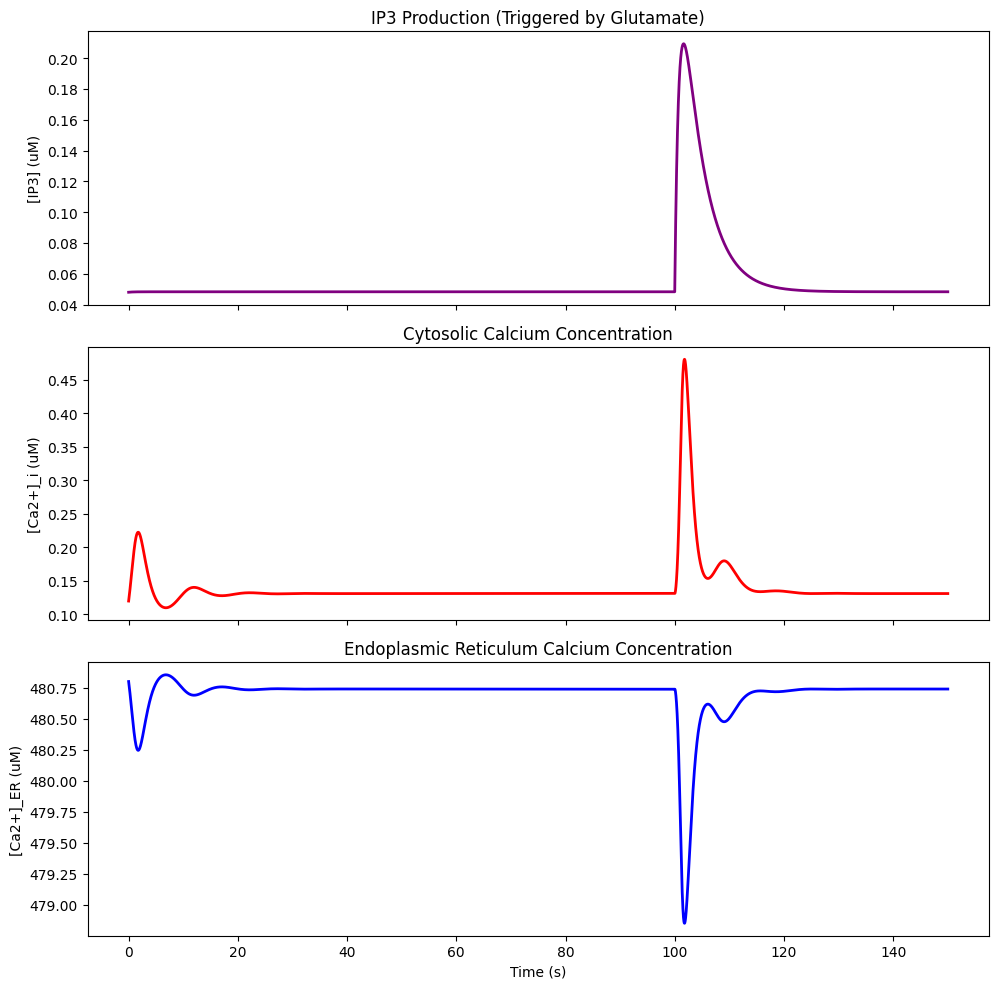

In [166]:


t_ca = np.linspace(0, 150, 150_001)

# Initial conditions [Ca_a, s_ER, IP3, h]
y0_ca = [params['Ca_a_init'], params['s_init'], params['IP3_init'], params['h_init']]

# Solve the ODE
sol_ca = odeint(astrocyte_calcium_only_dynamics, y0_ca, t_ca, args=(params,))

Ca_a_sol_ca = sol_ca[:, 0]
s_ER_sol_ca = sol_ca[:, 1]
IP3_sol_ca = sol_ca[:, 2]

# Plotting
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# 1. IP3 Dynamics
axs[0].plot(t_ca, IP3_sol_ca, color='purple', lw=2)
axs[0].set_ylabel('[IP3] (uM)')
axs[0].set_title('IP3 Production (Triggered by Glutamate)')

# 2. Cytosolic Calcium
axs[1].plot(t_ca, Ca_a_sol_ca, color='red', lw=2)
axs[1].set_ylabel('[Ca2+]_i (uM)')
axs[1].set_title('Cytosolic Calcium Concentration')

# 3. ER Calcium
axs[2].plot(t_ca, s_ER_sol_ca, color='blue', lw=2)
axs[2].set_ylabel('[Ca2+]_ER (uM)')
axs[2].set_xlabel('Time (s)')
axs[2].set_title('Endoplasmic Reticulum Calcium Concentration')

plt.tight_layout()
plt.show()

# Simulation 0b: Receptor kinetics test (2 second window)

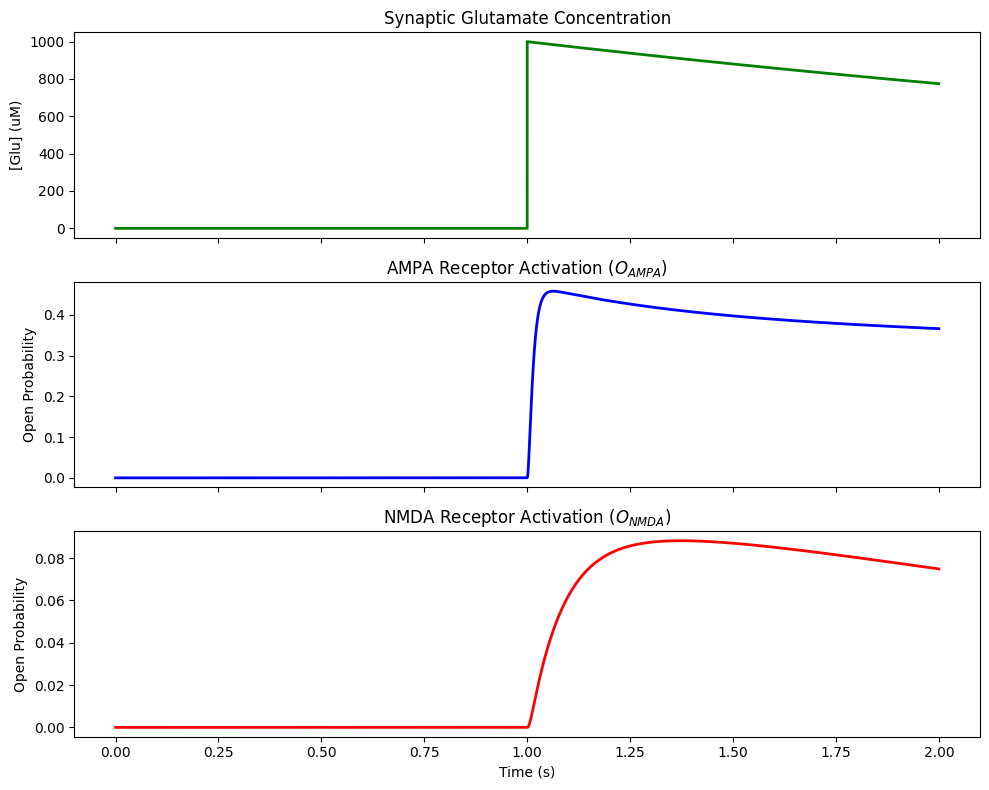

In [167]:
# Running the Simulation --- TESTING

# Use a very fine time step for receptor kinetics (2 seconds total)
t_rec = np.linspace(0, 2, 20_000)

# Initial conditions [AR, A2R, A2D, O_NMDA, C1, C2, D1, D2, O_AMPA]
y0_rec = [
    params['AR_init'], params['A2R_init'], params['A2D_init'], params['O_NMDA_init'],
    params['C1_init'], params['C2_init'], params['D1_init'], params['D2_init'], params['O_AMPA_init']
]

# Solve the ODE
sol_rec = odeint(receptor_kinetics_only, y0_rec, t_rec, args=(params,))

# Extract the open probabilities
O_NMDA_sol_rec = sol_rec[:, 3]
O_AMPA_sol_rec = sol_rec[:, 8]

# Calculate the Glutamate pulse for plotting
# Glu_sol = np.array([Glu_t_realistic(t) for t in t_rec])

Glu_sol = np.array([Glu_t_realistic(t, Glu_peak=[1000], t_release=[1.0], tau_decay=3.92) for t in t_rec]) # Calculate the Glutamate pulse for plotting using the same fast parameters for the 2 second test
#Glu_sol = np.array([Glu_t_realistic(t, Glu_peak=[200,400,800,1000], t_release=[0.2, 0.6, 1.0, 1.4], tau_decay=0.1) for t in t_rec]) # Calculate the Glutamate pulse for plotting using the same fast parameters for the 2 second test

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# 1. Glutamate Stimulus
axs[0].plot(t_rec, Glu_sol, color='green', lw=2)
axs[0].set_ylabel('[Glu] (uM)')
axs[0].set_title('Synaptic Glutamate Concentration')

# 2. AMPA Open Probability
axs[1].plot(t_rec, O_AMPA_sol_rec, color='blue', lw=2)
axs[1].set_ylabel('Open Probability')
axs[1].set_title('AMPA Receptor Activation ($O_{AMPA}$)')

# 3. NMDA Open Probability
axs[2].plot(t_rec, O_NMDA_sol_rec, color='red', lw=2)
axs[2].set_ylabel('Open Probability')
axs[2].set_xlabel('Time (s)')
axs[2].set_title('NMDA Receptor Activation ($O_{NMDA}$)')

plt.tight_layout()
plt.show()

# Simulation 1: only sodium dynamics

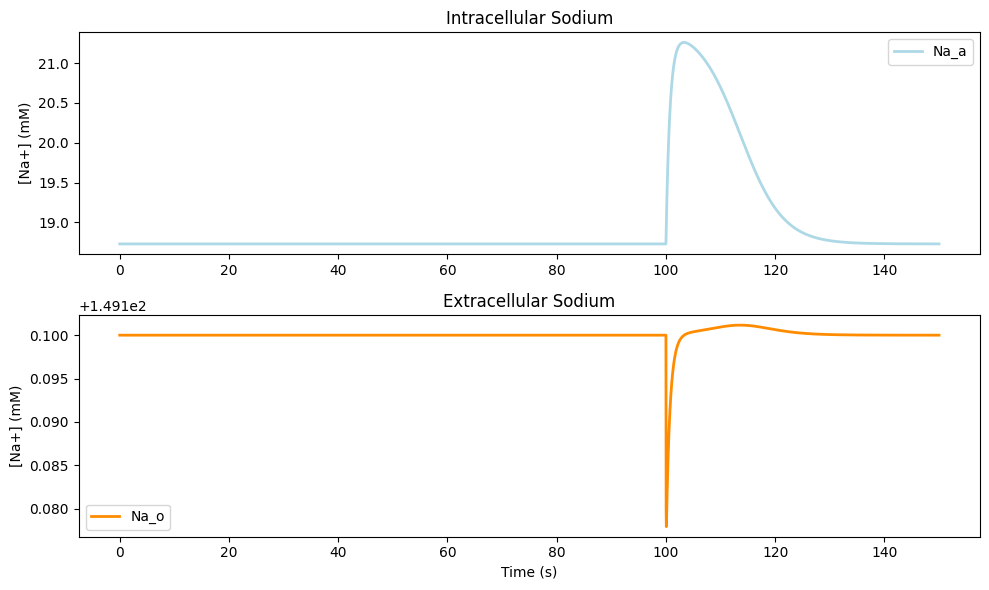

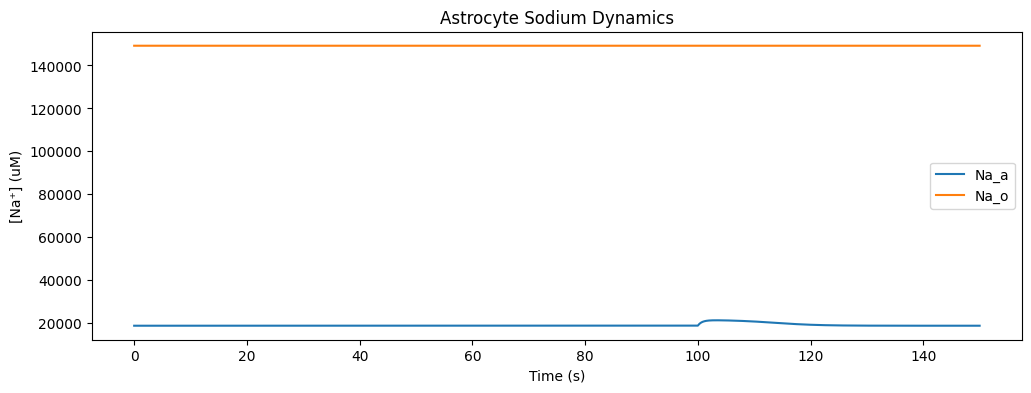

In [168]:
t_sim1 = np.linspace(0, 150, 150_001)  # 0 to 150 seconds # so the timestep is 0.001 seconds

# Initial conditions
y0_sim1 = [params['Na_a'], params['Na_o']]

# Solve ODE
solution_sim1 = odeint(astrocyte_na_dynamics, y0_sim1, t_sim1, args=(params,))

# Extract results
Na_a_sol_sim1 = solution_sim1[:, 0]
Na_o_sol_sim1 = solution_sim1[:, 1]

#Plot for sodium only dynamics (separate)
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t_sim1, Na_a_sol_sim1/1000, label='Na_a', color='lightblue', lw=2)
plt.ylabel('[Na+] (mM)')
plt.title('Intracellular Sodium')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t_sim1, Na_o_sol_sim1/1000, label='Na_o', color='darkorange', lw=2)
plt.ylabel('[Na+] (mM)')
plt.xlabel('Time (s)')
plt.title('Extracellular Sodium')
plt.legend()

plt.tight_layout()
plt.show()

#Plot for sodium only dynamics (together)
plt.figure(figsize=(12, 4))
plt.plot(t_sim1, Na_a_sol_sim1, label='Na_a')
plt.plot(t_sim1, Na_o_sol_sim1, label='Na_o')
plt.xlabel('Time (s)')
plt.ylabel('[Na⁺] (uM)')
plt.title('Astrocyte Sodium Dynamics')
plt.legend()
plt.show()

In [169]:
def audit_terms(Na_a, Na_o, t, p):
    Glu   = Glu_t_realistic(t)
    I_leak = J_Na(Na_a, Na_o,p['v'], p)
    I_pump = J_NaK(Na_a, p['K_o'], p)
    I_nkcc = J_NKCC(Na_a,params['K_a'],params['Cl_a'], Na_o, params['K_o'], params['Cl_o'], p)
    I_nbc  = J_NBC(Na_a, Na_o,p['v'],p)
    I_nhe  = J_NHE(Na_a, Na_o, p['v'],p)
    I_ncx  = J_NCX(Na_a, Na_o, p['Ca_a'], p['Ca_o'],p['v'], p)
    I_glut = J_GluT(Na_o, p['K_a'], Glu, p)
    conv   = p['rho_conv']
    dNa_i  = (-I_leak - 3*I_pump + I_nkcc + I_nbc - I_nhe
              -3*I_ncx*conv + 3*I_glut*conv)
    print(f"[audit t={t:.3f}s] μM/s terms:",
          {'-leak':-I_leak,'-3*pump':-3*I_pump,'+nkcc':I_nkcc,'+nbc':I_nbc,
           '-nhe':-I_nhe,'-3*ncx':-3*I_ncx*conv,'+3*glut':3*I_glut*conv,
           'SUM dNa_i': dNa_i})


t_checks = [0, 50.2, 150]
for tc in t_checks:
    k = np.searchsorted(t_sim1, tc)
    Na_a, Na_o = solution_sim1[k, 0], solution_sim1[k, 1]
    audit_terms(Na_a, Na_o, t_sim1[k], params)

[audit t=0.000s] μM/s terms: {'-leak': np.float64(24745.680483461358), '-3*pump': np.float64(-40556.38251669047), '+nkcc': np.float64(1139.3488710677834), '+nbc': np.float64(-4043.150120670749), '-nhe': np.float64(18728.573284638253), '-3*ncx': np.float64(-14.0724541904003), '+3*glut': np.float64(0.0), 'SUM dNa_i': np.float64(-0.002452384227787263)}
[audit t=50.200s] μM/s terms: {'-leak': np.float64(24745.68087095584), '-3*pump': np.float64(-40556.38107288599), '+nkcc': np.float64(1139.3488926720634), '+nbc': np.float64(-4043.149825463439), '-nhe': np.float64(18728.573580432632), '-3*ncx': np.float64(-14.072445761563257), '+3*glut': np.float64(0.0), 'SUM dNa_i': np.float64(-5.045684581261867e-08)}
[audit t=150.000s] μM/s terms: {'-leak': np.float64(24745.618756949156), '-3*pump': np.float64(-40556.61255773204), '+nkcc': np.float64(1139.34542958175), '+nbc': np.float64(-4043.1971461603), '-nhe': np.float64(18728.526165630057), '-3*ncx': np.float64(-14.073796922260854), '+3*glut': np.flo

In [170]:
# Drift analysis

drift_uM = solution_sim1[-1, 0] - solution_sim1[0, 0]
drift_mM = drift_uM / 1000.0 # mM

print(f"\nInitial Na_a: {solution_sim1[0,0]/1000:.2f} mM")
print(f"Final Na_a:   {solution_sim1[-1,0]/1000:.2f} mM")
print(f"Drift:        {drift_mM:+.3f} mM over 150s")


Initial Na_a: 18.73 mM
Final Na_a:   18.73 mM
Drift:        +0.000 mM over 150s


# Simulation 2: sodium, potassium and chlorine dynamics

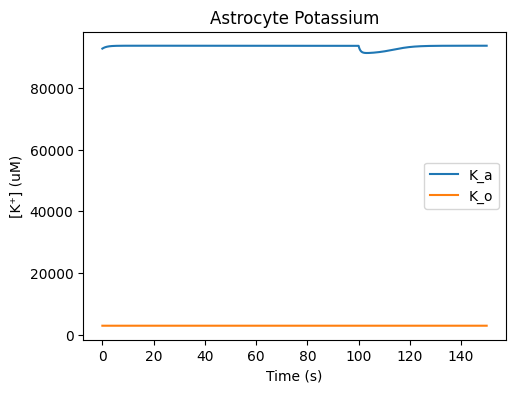

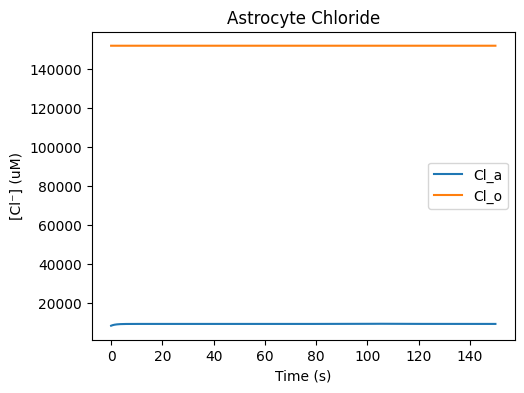

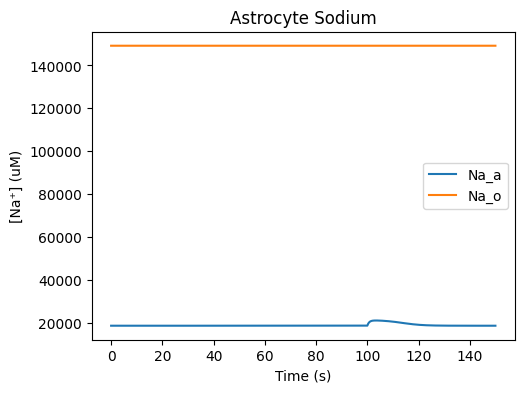

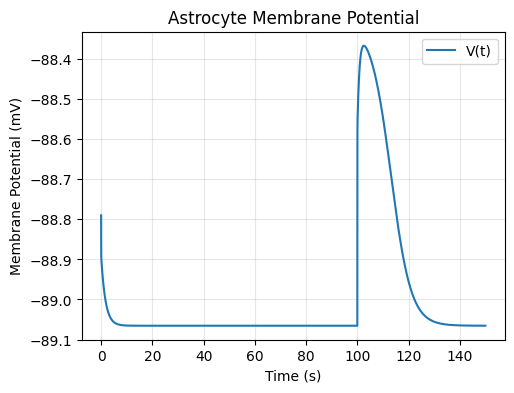

In [171]:
#Calcium dynamics are not added yet

t_sim2 = np.linspace(0, 150, 150_001)  # 0 to 150 seconds # so the timestep is 0.001 seconds

# Initial conditions
y0_sim2 = [params['Na_a'], params['Na_o'],
      params['K_a'], params['K_o'],
      params['Cl_a'], params['Cl_o'], params['v']]

# Solve ODE
solution_sim2 = odeint(astrocyte_full_dynamics, y0_sim2, t_sim2, args=(params,))

# Extract results
Na_a_sol_sim2 = solution_sim2[:, 0]
Na_o_sol_sim2 = solution_sim2[:, 1]
K_a_sol_sim2 = solution_sim2[:, 2]
K_o_sol_sim2 = solution_sim2[:, 3]
Cl_a_sol_sim2 = solution_sim2[:, 4]
Cl_o_sol_sim2 = solution_sim2[:, 5]
V_sol_sim2 = solution_sim2[:,6]

#Plots for full dynamics (without calcium and nmda and ampa)
#Potassium (outside and inside) dynamics over time
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t_sim2, K_a_sol_sim2, label='K_a')
plt.plot(t_sim2, K_o_sol_sim2, label='K_o')
plt.xlabel('Time (s)')
plt.ylabel( '[K⁺] (uM)')
plt.title('Astrocyte Potassium')
plt.legend()
plt.show()

#Chloride (outside and inside) dynamics over time
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t_sim2, Cl_a_sol_sim2, label='Cl_a')
plt.plot(t_sim2, Cl_o_sol_sim2, label='Cl_o')
plt.xlabel('Time (s)')
plt.ylabel('[Cl⁻] (uM)')
plt.title('Astrocyte Chloride')
plt.legend()
plt.show()

#Sodium (outside and inside) dynamics over time
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t_sim2, Na_a_sol_sim2, label='Na_a')
plt.plot(t_sim2, Na_o_sol_sim2, label='Na_o')
plt.xlabel('Time (s)')
plt.ylabel('[Na⁺] (uM)')
plt.title('Astrocyte Sodium')
plt.legend()
plt.show()

#Voltage over time
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t_sim2, V_sol_sim2, label='V(t)')
plt.xlabel('Time (s)')
plt.ylabel('Membrane Potential (mV)')
plt.title('Astrocyte Membrane Potential')
plt.legend()
plt.grid(alpha=0.3)


In [172]:
# Drift analysis
for ion_name, conc in [('Na_a', Na_a_sol_sim2), ('Na_o', Na_o_sol_sim2),
                        ('K_a', K_a_sol_sim2), ('K_o', K_o_sol_sim2),
                        ('Cl_a', Cl_a_sol_sim2), ('Cl_o', Cl_o_sol_sim2)]:
    initial = conc[0] / 1000  # mM
    final = conc[-1] / 1000   # mM
    drift = final - initial
    print(f"{ion_name:6s}: {initial:7.2f} → {final:7.2f} mM  (Drift: {drift:+.3f} mM)")

Na_a  :   18.73 →   18.72 mM  (Drift: -0.006 mM)
Na_o  :  149.20 →  149.20 mM  (Drift: +0.000 mM)
K_a   :   92.68 →   93.61 mM  (Drift: +0.933 mM)
K_o   :    2.93 →    2.93 mM  (Drift: -0.000 mM)
Cl_a  :    8.21 →    9.14 mM  (Drift: +0.927 mM)
Cl_o  :  152.13 →  152.13 mM  (Drift: +0.000 mM)


# Simulation 3: full dynamics (with added calcium and ampa and nmda)

In [173]:

# Expanded initial conditions (20 variables)
y0_full = [
    params['Na_a'], params['Na_o'], params['K_a'], params['K_o'], params['Cl_a'], params['Cl_o'], params['v'],
    params['Ca_a_init'], params['s_init'], params['IP3_init'], params['h_init'],
    params['AR_init'], params['A2R_init'], params['A2D_init'], params['O_NMDA_init'],
    params['C1_init'], params['C2_init'], params['D1_init'], params['D2_init'], params['O_AMPA_init']
]

# Note: use a smaller time array initially (20 seconds) just to make sure it solves quickly #march 11: 150 seconds
t_full = np.linspace(0, 150, 150_001)

# Solve ODE
solution_full = odeint(astrocyte_full_dynamics_v2, y0_full, t_full, args=(params,))

# Simulation 3: master plots

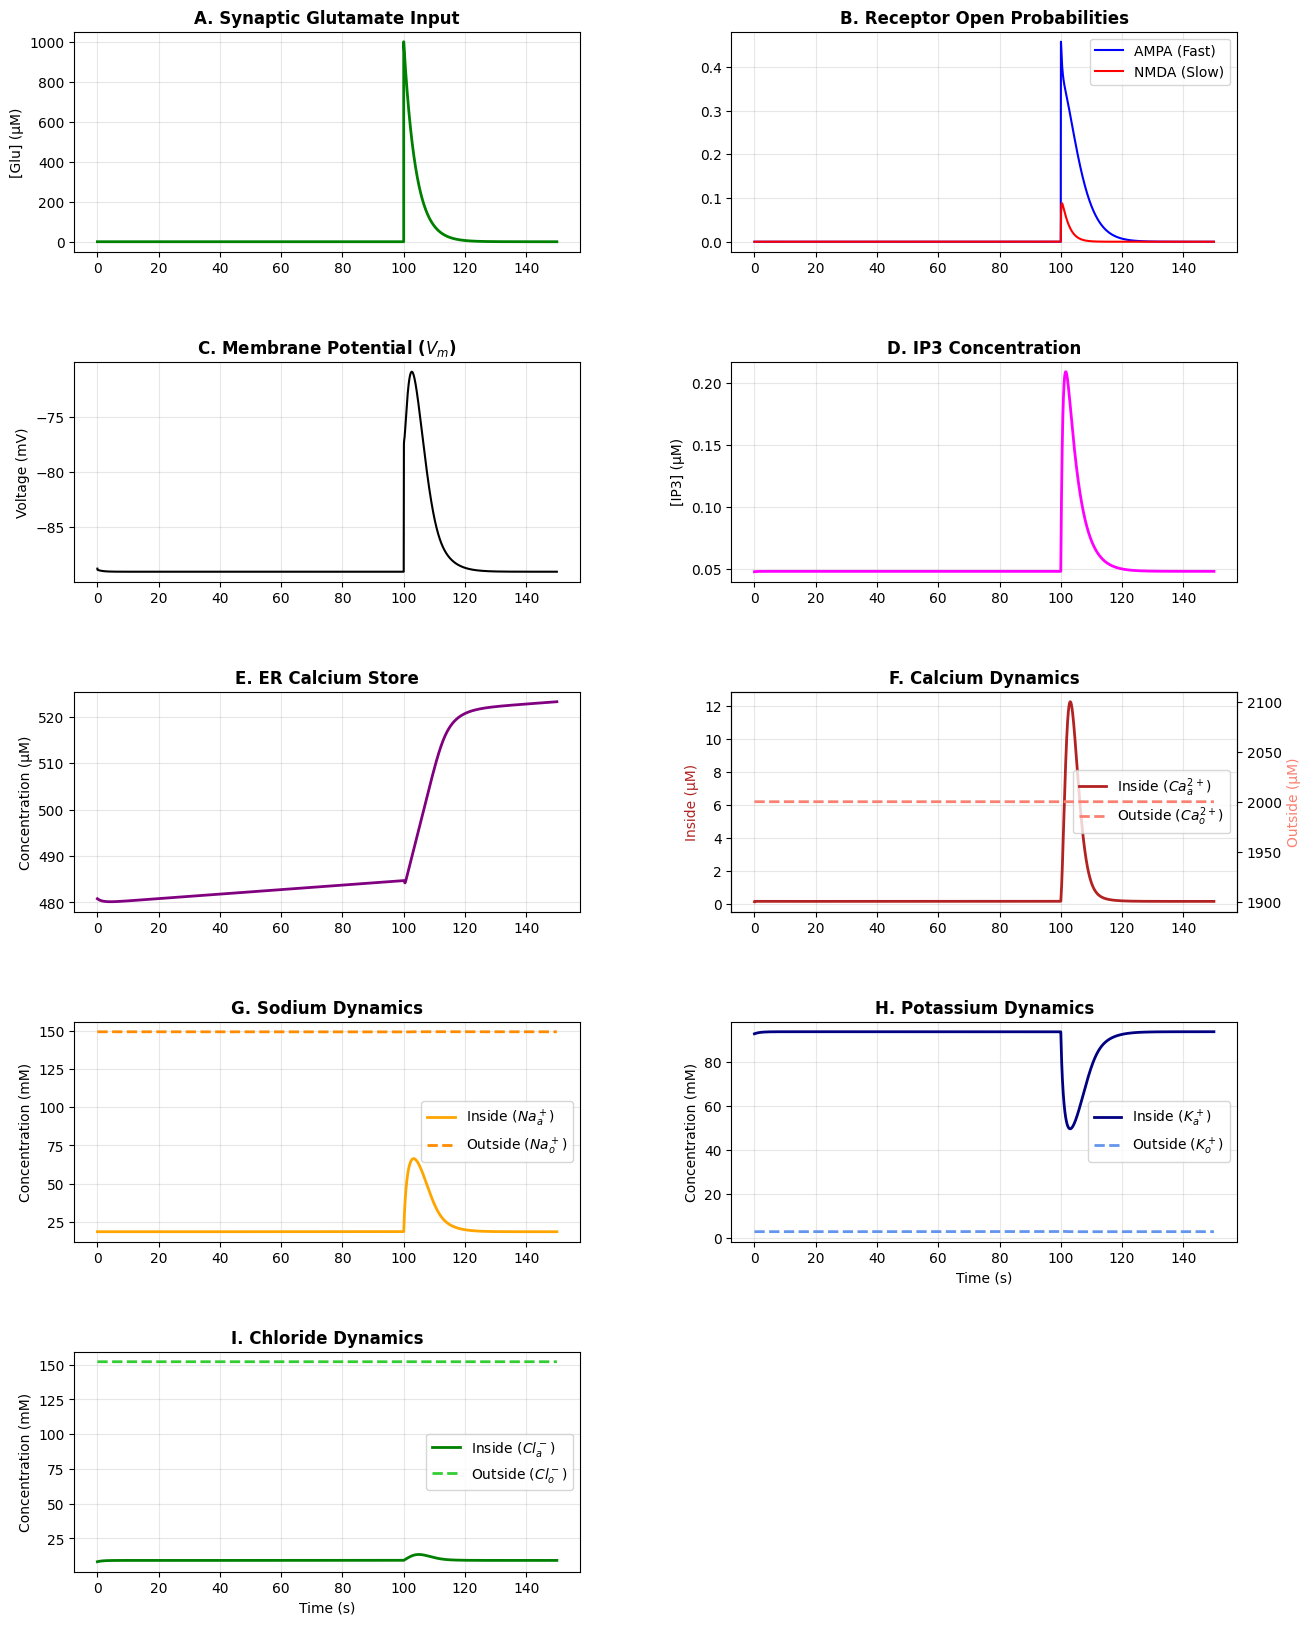

In [174]:
# Plots for simulation 3


# 1. Extract the key variables from the big solution matrix
# Using solution_full and t_full directly

Na_a_sol_sim3 = solution_full[:, 0] / 1000.0  # Convert uM -> mM
Na_o_sol_sim3 = solution_full[:, 1] / 1000.0  # Convert uM -> mM

K_a_sol_sim3  = solution_full[:, 2] / 1000.0  # Convert uM -> mM
K_o_sol_sim3  = solution_full[:, 3] / 1000.0  # Convert uM -> mM

Cl_a_sol_sim3 = solution_full[:, 4] / 1000.0  # Convert uM -> mM
Cl_o_sol_sim3 = solution_full[:, 5] / 1000.0  # Convert uM -> mM

Ca_a_sol = solution_full[:, 7]           # Keep in uM (very small)
# Ca_o is constant in this version, creating an array for plotting
Ca_o_sol = np.full_like(t_full, params['Ca_o']) # Keep in uM
v_sol    = solution_full[:, 6]   # Voltage
s_ER_sol = solution_full[:, 8]   # ER Calcium
IP3_sol  = solution_full[:, 9]   # IP3
O_NMDA_sol = solution_full[:, 14] # NMDA Open Prob
O_AMPA_sol = solution_full[:, 19] # AMPA Open Prob

# Re-calculate the Glutamate pulse for plotting (so we can see the stimulus) -> when plot, you need to reestablish to differ from the original general glutamate_function at the beginning
Glu_plot = np.array([Glu_t_realistic(t, Glu_peak=[1000], t_release=[100], tau_decay=3.92) for t in t_full])

# 2. Create the 5x2 Master Figure
fig, axs = plt.subplots(5, 2, figsize=(15, 20)) # Increased height for 5 rows
plt.subplots_adjust(hspace=0.5, wspace=0.3)

# Plot A: The Stimulus (Glutamate)
axs[0, 0].plot(t_full, Glu_plot, color='green', lw=2)
axs[0, 0].set_title('A. Synaptic Glutamate Input', fontweight='bold')
axs[0, 0].set_ylabel('[Glu] (µM)')
axs[0, 0].grid(alpha=0.3)

# Plot B: Receptor Activation
axs[0, 1].plot(t_full, O_AMPA_sol, label='AMPA (Fast)', color='blue')
axs[0, 1].plot(t_full, O_NMDA_sol, label='NMDA (Slow)', color='red')
axs[0, 1].set_title('B. Receptor Open Probabilities', fontweight='bold')
axs[0, 1].legend()
axs[0, 1].grid(alpha=0.3)

# Plot C: Membrane Potential
axs[1, 0].plot(t_full, v_sol, color='black', lw=1.5)
axs[1, 0].set_title('C. Membrane Potential ($V_m$)', fontweight='bold')
axs[1, 0].set_ylabel('Voltage (mV)')
axs[1, 0].grid(alpha=0.3)

# Plot D: IP3 (The Messenger)
axs[1, 1].plot(t_full, IP3_sol, color='magenta', lw=2)
axs[1, 1].set_title('D. IP3 Concentration', fontweight='bold')
axs[1, 1].set_ylabel('[IP3] (µM)')
axs[1, 1].grid(alpha=0.3)

# Plot E: ER Calcium Store
axs[2, 0].plot(t_full, s_ER_sol, color='purple', lw=2)
axs[2, 0].set_title('E. ER Calcium Store', fontweight='bold')
axs[2, 0].set_ylabel('Concentration (µM)')
axs[2, 0].grid(alpha=0.3)

# Plot F: Calcium (Inside vs Outside - Dual Axis)
ax_ca_in = axs[2, 1]
ax_ca_out = ax_ca_in.twinx()
ln1 = ax_ca_in.plot(t_full, Ca_a_sol, label='Inside ($Ca^{2+}_a$)', color='firebrick', lw=2)
ln2 = ax_ca_out.plot(t_full, Ca_o_sol, label='Outside ($Ca^{2+}_o$)', color='salmon', linestyle='--', lw=2)
ax_ca_in.set_title('F. Calcium Dynamics', fontweight='bold')
ax_ca_in.set_ylabel('Inside (µM)', color='firebrick')
ax_ca_out.set_ylabel('Outside (µM)', color='salmon')
lns = ln1 + ln2
labs = [l.get_label() for l in lns]
ax_ca_in.legend(lns, labs, loc='center right')
ax_ca_in.grid(alpha=0.3)

# Plot G: Sodium (Inside vs Outside)
axs[3, 0].plot(t_full, Na_a_sol_sim3, label='Inside ($Na^+_a$)', color='orange', lw=2)
axs[3, 0].plot(t_full, Na_o_sol_sim3, label='Outside ($Na^+_o$)', color='darkorange', linestyle='--', lw=2)
axs[3, 0].set_title('G. Sodium Dynamics', fontweight='bold')
axs[3, 0].set_ylabel('Concentration (mM)')
axs[3, 0].legend()
axs[3, 0].grid(alpha=0.3)

# Plot H: Potassium (Inside vs Outside)
axs[3, 1].plot(t_full, K_a_sol_sim3, label='Inside ($K^+_a$)', color='navy', lw=2)
axs[3, 1].plot(t_full, K_o_sol_sim3, label='Outside ($K^+_o$)', color='cornflowerblue', linestyle='--', lw=2)
axs[3, 1].set_title('H. Potassium Dynamics', fontweight='bold')
axs[3, 1].set_ylabel('Concentration (mM)')
axs[3, 1].legend()
axs[3, 1].grid(alpha=0.3)

# Plot I: Chloride (Inside vs Outside)
axs[4, 0].plot(t_full, Cl_a_sol_sim3, label='Inside ($Cl^-_a$)', color='green', lw=2)
axs[4, 0].plot(t_full, Cl_o_sol_sim3, label='Outside ($Cl^-_o$)', color='limegreen', linestyle='--', lw=2)
axs[4, 0].set_title('I. Chloride Dynamics', fontweight='bold')
axs[4, 0].set_ylabel('Concentration (mM)')
axs[4, 0].set_xlabel('Time (s)')
axs[4, 0].legend()
axs[4, 0].grid(alpha=0.3)

# Hide the 10th empty plot to keep it clean
axs[4, 1].axis('off')

# Ensure xlabels only appear on the bottom row where visible
axs[3, 1].set_xlabel('Time (s)')

plt.show()